In [2]:
# design function to take 2 input seabass files, and write an ag_merge seabass file to a
# specified location


# link to paper: http://doi.org/10.1002/lom3.70044

In [1]:
import sys
from SB_support import *    # the sb_support module is included in this repository, retrieved from https://seabass.gsfc.nasa.gov/wiki/readsb_python
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
def vth_merge(carydat, wgdat, lambda1threshold=1.3818, lambda2threshold=0.4):
    # based on Trolley et al. 2026 L&O Methods: http://doi.org/10.1002/lom3.70044
    # function to compute value threshold merge approach, customize lambda2 threshold
    # for cary + ultrapath ag data
    # carydat and wgdat are (601,) length numpy.ndarrays
    # returns merged output (601 len)
    # also returns wlmin and wlmax (use for histograms)
    #ex usage: 
    # merge, wvmin, wvmax = custom_vth_merge(carydat, wgdat, 0.4)

    # this edition of function allows you to input the threshold values,
    # use for less conservative comparison

    # for this single sample, combing cary and ultrapath measurements to 1 df with uniform index
    u = pd.DataFrame(wgdat.copy())[['wavelength', 'ag']].set_index('wavelength').sort_index().rename(columns={"ag": "ultra_ag"})
    new_index = np.arange(int(u.index.min()), int(u.index.max()) + 1)
    u = u.reindex(new_index, method='nearest')

    c = pd.DataFrame(carydat.copy())[['wavelength', 'ag']].set_index('wavelength').sort_index().rename(columns={"ag": "cary_ag"})
    new_index = np.arange(int(c.index.min()), int(c.index.max()) + 1)
    c = c.reindex(new_index, method='nearest')

    u.index = u.index.astype('float')
    c.index = c.index.astype('float')
    ucdf = pd.concat([u,c], axis = 1)
    ucdf.sort_index(inplace=True)

    wg_max_idx = int(np.nanargmax(ucdf['ultra_ag']))# returns index of max wg ag datapoint
    ucdf.iloc[0:wg_max_idx, ucdf.columns.get_loc('ultra_ag')] = np.nan  # mask all data before max, remove positive slope region
    cary_max_idx = int(np.nanargmax(ucdf['cary_ag']))# returns index of max cary ag datapoint
    ucdf.iloc[0:cary_max_idx, ucdf.columns.get_loc('cary_ag')] = np.nan  # mask all data before max, remove some scan errors

    try:
        wvmin = int(np.where(ucdf['ultra_ag']>lambda1threshold)[0][-1])# returns last index before waveguide ag goes below 1.3818
    except:
        wvmin = int(wg_max_idx)
        

    wvmax = np.where(ucdf['cary_ag']<lambda2threshold)[0][0]# returns first index where cary ag < 0.4
    
    x_interp=np.arange(wvmin, wvmax+1)

    # next up, set up and execute interpolation
    y_interp=np.linspace(0,1,len(x_interp))# linear interp from 0 to 1
    
    merged_part1 = ucdf.iloc[:wvmin, ucdf.columns.get_loc('cary_ag')]#begining part of merged spectra is 100% cary
    merged_part3 = ucdf.iloc[wvmax+1:, ucdf.columns.get_loc('ultra_ag')]# end part of merged spectra is 100% WG
    
    # # Merged part2: 
    wg_mid = ucdf.iloc[wvmin:wvmax+1, ucdf.columns.get_loc('ultra_ag')]
    cary_mid= ucdf.iloc[wvmin:wvmax+1, ucdf.columns.get_loc('cary_ag')]
    merged_part2=wg_mid*y_interp + cary_mid*(1-y_interp)
    
    #print(len(merged_part1), len(merged_part2), len(merged_part3))
    # #complete the merge, 2 append statements to combine the 3 parts
    merged_parts1_2=np.append(merged_part1,merged_part2)
    merged_complete=np.append(merged_parts1_2, merged_part3)
    ucdf['vth_merge']=merged_complete

    return ucdf, int(wvmin), int(wvmax)

def make_data_csv(data):# you shouldn't need to change this function regularly
    # input is dictionary for a particular sequence in final data for the .sb file, output is a csv ready to write 
    # (i.e., the data converted to text, which is later written to the file right after the header)
    
    data = data.reset_index()
    sub_df=data[['wavelength','vth_merge']] # select columns to write
    sub_df = sub_df.dropna()
    sub_df=sub_df.fillna(-9999) # change any nans to the missing data value

    # manually set number of decimal places to write for each column
    sub_df['wavelength'] = sub_df['wavelength'].map('{:.0f}'.format)
    sub_df['vth_merge'] = sub_df['vth_merge'].map('{:.6f}'.format)  

    csv=sub_df.to_csv(header=None, index=False, lineterminator = '\n').strip('\n').split('\n')# convert dataframe to csv

    for i in range(len(csv)):
        csv[i]=csv[i].replace('-9999.000000', '-9999')# manually change the missing data back to 0 decimal places. optional, but cleaner 

    return csv

In [7]:
def ag_merge(ultra_file, cary_file, odir=''):
    # function to compute value threshold ag merge, according to trolley et al 2026
    # based on Trolley et al. 2026 L&O Methods: http://doi.org/10.1002/lom3.70044
    # take ultrapath and cary-100 ag files of same sample, and produce a single seabass file
    # specify output directory, if not specified will write to current directory
    # output filename is automatically generated based on input files

    #semi variables:
    ultra_dir = 'ultrapath_files/'
    cary_dir = 'cary_files/'
    write_location = 'merged_sb_files/'

    # part 1 : conduct merge

    ultra_sb = readSB(filename=ultra_dir+ultra_file, no_warn=True)
    cary_sb = readSB(filename=cary_dir+cary_file, no_warn=True)
    cary_data = cary_sb.data
    ultra_data = ultra_sb.data

    merge = vth_merge(cary_data, ultra_data, lambda1threshold=1.3818, lambda2threshold=0.4)#0.4 is lambda2 limit determined by Trolley et al 2026
    lambda1 = merge[0].index[merge[1]]
    lambda2 = merge[0].index[merge[2]]
    #print(lambda1, lambda2)
    
    # seabass comment info
    sb_comments = {
        'lambda1_threshold': 1.3818,
        'lambda2_threshold': 0.4,
        'lambda1': lambda1,
        'lambda2': lambda2
    }

    # part 2: build seabass file
    data_csv = make_data_csv(merge[0])
    
    # part 3: build header
    hlist = make_ag_merge_header(ultra_sb, cary_sb, sb_comments,
                                investigators='Antonio_Mannino,Graham_Trolley', 
                                affiliations='NASA_Goddard_Space_Flight_Center,NASA_Goddard_Space_Flight_Center', 
                                contact='antonio.mannino-1@nasa.gov,graham.r.trolley@nasa.gov',)
    oname =  [line.split("/data_file_name=")[1].strip() for line in hlist if "/data_file_name=" in line][0]
    print(oname)
    # part 4: write file
    with open(odir+oname, 'w') as the_file:# open file to write
        for hrow in hlist:
            the_file.write(hrow)# write header to output file first, row by row
        for x in data_csv:
            the_file.write(x+'\n')# then, write the data row by row
    print('Wrote '+oname)

    return merge, ultra_sb, cary_sb, sb_comments

In [ ]:
def make_ag_merge_header(ultra_sb, cary_sb, sb_comments, revision=1, investigators=1, affiliations=1, contact=1, documents=1, calibration_files='see_source_files'):
    # function to make header for ag merge file, based on the header of the ultrapath file, with some edits
    # input is the two original seabass files, output is a dictionary of header info for the merged file
    # revision: optional, default 1. refers to R# at end of filename, e.g. R1.sb
    # sb_comments is a dictionary of comments to add to the header: thresh1, thresh2, lambda1, lambda2
    # if investigators, affiliations, contact, or documents are set to 1, the function will auto populate, 
    # but specific strings can also be used for those arguments

    merge_headers = ultra_sb.headers.copy()
    # Many headers can be recycled from one of the 2 input data, I choose to use the ultra header here
    # but, some headers are no longer relevant (reciieved, documents, intrument_mmodel, etc) and should be deleted first

    headers_to_del = ['received','identifier_product_doi',  'instrument_manufacturer', 'instrument_model', 'path_length']
    for h in headers_to_del:
        if h in merge_headers:
            del merge_headers[h]

    merge_headers['data_file_name'] = ultra_sb.headers['experiment']+'_'+ultra_sb.headers['cruise']+'_'+'ag_merge_'+ultra_sb.headers['start_date']+'_'+'st'+ultra_sb.headers['station']+'_'+ultra_sb.headers['measurement_depth']+'m_R'+str(int(revision))+'.sb'

    #logic for affiliations, investigators, contact: if an input was specified, use that. if not, combine the info from the 2 input files (removing duplicates)
    if investigators == 1:
        combined_investigators = ','.join(set(ultra_sb.headers['investigators'].split(',')) | set(cary_sb.headers['investigators'].split(',')))
        merge_headers['investigators'] = combined_investigators
    else:
        merge_headers['investigators'] = investigators.replace(' ', '')

    if affiliations == 1:
        combined_affiliations = ','.join(set(ultra_sb.headers['affiliations'].split(',')) | set(cary_sb.headers['affiliations'].split(',')))
        merge_headers['affiliations'] = combined_affiliations
    else:
        merge_headers['affiliations'] = affiliations.replace(' ', '')

    if contact == 1:
        combined_contact = ','.join(set(ultra_sb.headers['contact'].split(',')) | set(cary_sb.headers['contact'].split(',')))
        merge_headers['contact'] = combined_contact
    else:
        merge_headers['contact'] = contact.replace(' ', '')

    if documents == 1:
        merge_headers['documents'] = 'CDOM_merge.docx'
    else:
        merge_headers['documents'] = documents
        
    merge_headers['calibration_files']=calibration_files
    merge_headers['delimiter']='comma'
    merge_headers['missing']='-9999'
    merge_headers['bincount']='1'
    merge_headers['fields']='wavelength,ag'
    merge_headers['units']='nm,1/m'

    hlist=[]
    hlist.append('/begin_header\n')
    for i in merge_headers.keys():
        hlist.append('/'+i+'='+merge_headers[i]+'\n')
    hlist.append('/end_header\n')

    # comments to add: description of method, lambda1, lambda2, thresh1, thresh2, file1, file2
    comments = ['!\n', 
                '! ag data merged from 2 spectrometers, according to value threshold merge approach described in Trolley et al. 2026 http://doi.org/10.1002/lom3.70044\n',
                '! data from the short pathlength instrument is used at short wavelengths, data from the long pathlength instrument is used at long wavelengths, and a weighted average is used in between\n',
                '! the merge is applied to the processed values reported in the "ag" column of the source files\n',
                '! long_pathlength_fname='+ultra_sb.headers['data_file_name']+'\n',
                '! short_pathlength_fname='+cary_sb.headers['data_file_name']+'\n',
                #'! lambda1='+str(sb_comments['lambda1'])+'(nm)\n',
                #'! lambda2='+str(sb_comments['lambda2'])+'(nm)\n',
                '! lambda1_threshold='+str(sb_comments['lambda1_threshold'])+'(m^-1)\n',
                '! lambda2_threshold='+str(sb_comments['lambda2_threshold'])+'(m^-1)\n'
                '!/wavelength_merge_thresholds=ag_merge'+str(sb_comments['lambda1'])+':ag_merge'+str(sb_comments['lambda2'])+'\n',
                '!\n']
    hlist[-3:-3] = comments


    return hlist

In [14]:
merge, ultra_sb, cary_sb, sb_comments = ag_merge('CliVEC_CV3_Ultrapath_waveguide_ag_20100215_st68_00m_R1.sb', 'CV3_ag_st68_00m.sb','')

CliVEC_CV3_ag_merge_20100215_st68_00m_R1.sb
Wrote CliVEC_CV3_ag_merge_20100215_st68_00m_R1.sb


In [13]:
#od.keys()
sb_comments

{'lambda1_threshold': 1.3818,
 'lambda2_threshold': 0.4,
 'lambda1': np.float64(278.0),
 'lambda2': np.float64(336.0)}

In [16]:
def get_cary_fname(sb):
    # given an Ultrapath sb file, parse the comments and retrieve the corresponding cary file name. works only for cruises included in this dataset
    comment_index = [i for i, s in enumerate(sb.comments) if 'paired_cary_ag_file:' in s]
    comment_line = sb.comments[comment_index[0]]
    cary_fname = comment_line[21:]
    return cary_fname

def make_ag_merge_header(ultra_sb, cary_sb, sb_comments, revision=1, investigators=1, affiliations=1, contact=1, documents=1, calibration_files='see_source_files'):
    # function to make header for ag merge file, based on the header of the ultrapath file, with some edits
    # input is the two original seabass files, output is a dictionary of header info for the merged file
    # revision: optional, default 1. refers to R# at end of filename, e.g. R1.sb
    # sb_comments is a dictionary of comments to add to the header: thresh1, thresh2, lambda1, lambda2
    # if investigators, affiliations, contact, or documents are set to 1, the function will auto populate, 
    # but specific strings can also be used for those arguments

    merge_headers = ultra_sb.headers.copy()
    # Many headers can be recycled from one of the 2 input data, I choose to use the ultra header here
    # but, some headers are no longer relevant (reciieved, documents, intrument_mmodel, etc) and should be deleted first

    headers_to_del = ['received','identifier_product_doi',  'instrument_manufacturer', 'instrument_model', 'path_length']
    for h in headers_to_del:
        if h in merge_headers:
            del merge_headers[h]

    merge_headers['data_file_name'] = ultra_sb.headers['experiment']+'_'+ultra_sb.headers['cruise']+'_'+'ag_merge_'+ultra_sb.headers['start_date']+'_'+'st'+ultra_sb.headers['station']+'_'+ultra_sb.headers['measurement_depth']+'m_R'+str(int(revision))+'.sb'

    #logic for affiliations, investigators, contact: if an input was specified, use that. if not, combine the info from the 2 input files (removing duplicates)
    if investigators == 1:
        combined_investigators = ','.join(set(ultra_sb.headers['investigators'].split(',')) | set(cary_sb.headers['investigators'].split(',')))
        merge_headers['investigators'] = combined_investigators
    else:
        merge_headers['investigators'] = investigators.replace(' ', '')

    if affiliations == 1:
        combined_affiliations = ','.join(set(ultra_sb.headers['affiliations'].split(',')) | set(cary_sb.headers['affiliations'].split(',')))
        merge_headers['affiliations'] = combined_affiliations
    else:
        merge_headers['affiliations'] = affiliations.replace(' ', '')

    if contact == 1:
        combined_contact = ','.join(set(ultra_sb.headers['contact'].split(',')) | set(cary_sb.headers['contact'].split(',')))
        merge_headers['contact'] = combined_contact
    else:
        merge_headers['contact'] = contact.replace(' ', '')

    if documents == 1:
        merge_headers['documents'] = 'CDOM_merge.docx'
    else:
        merge_headers['documents'] = documents
        
    merge_headers['calibration_files']=calibration_files
    merge_headers['delimiter']='comma'
    merge_headers['missing']='-9999'
    merge_headers['bincount']='1'
    merge_headers['fields']='wavelength,ag'
    merge_headers['units']='nm,1/m'

    hlist=[]
    hlist.append('/begin_header\n')
    for i in merge_headers.keys():
        hlist.append('/'+i+'='+merge_headers[i]+'\n')
    hlist.append('/end_header\n')

    # comments to add: description of method, lambda1, lambda2, thresh1, thresh2, file1, file2
    comments = ['!\n', 
                '! ag data merged from 2 spectrometers, according to value threshold merge approach described in Trolley et al. 2026 http://doi.org/10.1002/lom3.70044\n',
                '! data from the short pathlength instrument is used at short wavelengths, data from the long pathlength instrument is used at long wavelengths, and a weighted average is used in between\n',
                '! the merge is applied to the processed values reported in the "ag" column of the source files\n',
                '! long_pathlength_fname='+ultra_sb.headers['data_file_name']+'\n',
                '! short_pathlength_fname='+cary_sb.headers['data_file_name']+'\n',
                #'! lambda1='+str(sb_comments['lambda1'])+'(nm)\n',
                #'! lambda2='+str(sb_comments['lambda2'])+'(nm)\n',
                '! lambda1_threshold='+str(sb_comments['lambda1_threshold'])+'(m^-1)\n',
                '! lambda2_threshold='+str(sb_comments['lambda2_threshold'])+'(m^-1)\n'
                '!/wavelength_merge_thresholds=ag_merge'+str(sb_comments['lambda1'])+':ag_merge'+str(sb_comments['lambda2'])+'\n',
                '!\n']
    hlist[-3:-3] = comments


    return hlist

In [ ]:
# actual code to loop through files and build merged files for all samples in the dataset, using the above functions

substr = 'ECOA_3'

# build batch process
cary_dir = 'cary_files/'
ultra_dir = 'ultrapath_files/'
cary_flist = os.listdir(cary_dir)
ultra_flist = os.listdir(ultra_dir)
ultra_flist = sorted(ultra_flist)


odir = 'merged_files/'+substr+'/'
ultra_flist = [f for f in ultra_flist if substr in f]
os.makedirs(odir, exist_ok=True)

for ultra_file in ultra_flist:
    ultra_sb = readSB(filename=ultra_dir+ultra_file, no_warn=True)
    cary_file = get_cary_fname(ultra_sb)
    cary_sb = readSB(filename=cary_dir+cary_file, no_warn=True)
    #print('Merging '+ultra_file+' and '+cary_file)
    
    merge, ultra_sb, cary_sb, sb_comments = ag_merge(ultra_file, cary_file, odir=odir)

ECOA_ECOA-3_ag_merge_20220809_st5_12.0m_R1.sb
Wrote ECOA_ECOA-3_ag_merge_20220809_st5_12.0m_R1.sb
ECOA_ECOA-3_ag_merge_20220811_st20_190.0m_R1.sb
Wrote ECOA_ECOA-3_ag_merge_20220811_st20_190.0m_R1.sb
ECOA_ECOA-3_ag_merge_20220813_st31_28.0m_R1.sb
Wrote ECOA_ECOA-3_ag_merge_20220813_st31_28.0m_R1.sb
ECOA_ECOA-3_ag_merge_20220814_st33_4.2m_R1.sb
Wrote ECOA_ECOA-3_ag_merge_20220814_st33_4.2m_R1.sb
ECOA_ECOA-3_ag_merge_20220818_st58_22.0m_R1.sb
Wrote ECOA_ECOA-3_ag_merge_20220818_st58_22.0m_R1.sb
ECOA_ECOA-3_ag_merge_20220821_st77a_5.5m_R1.sb
Wrote ECOA_ECOA-3_ag_merge_20220821_st77a_5.5m_R1.sb
ECOA_ECOA-3_ag_merge_20220821_st77b_28.0m_R1.sb
Wrote ECOA_ECOA-3_ag_merge_20220821_st77b_28.0m_R1.sb
ECOA_ECOA-3_ag_merge_20220912_st166_2.9m_R1.sb
Wrote ECOA_ECOA-3_ag_merge_20220912_st166_2.9m_R1.sb
ECOA_ECOA-3_ag_merge_20220920_st205_2.6m_R1.sb
Wrote ECOA_ECOA-3_ag_merge_20220920_st205_2.6m_R1.sb
ECOA_ECOA-3_ag_merge_20220920_st205_72.4m_R1.sb
Wrote ECOA_ECOA-3_ag_merge_20220920_st205_72.4m_R1.s

In [129]:
ultra_sb.headers['investigators'],cary_sb.headers['investigators']
combined_investigators = ','.join(set(ultra_sb.headers['investigators'].split(',')) | set(cary_sb.headers['investigators'].split(',')))
combined_investigators

'Graham_Trolley,Antonio_Mannino,Michael_Novak,Margaret_Mulholland'

In [19]:
od = make_ag_merge_header(ultra_sb, cary_sb, sb_comments)
od

['/begin_header\n',
 '/investigators:Margaret_Mulholland,Michael_Novak,Antonio_Mannino,Graham_Trolley\n',
 '/affiliations:Old_Dominion_University,NASA_Goddard_Space_Flight_Center,Alfred-Wegener-Institute_Helmholtz_Centre_for_Polar_and_Marine_Research\n',
 '/contact:michael.novak@ssaihq.com,antonio.mannino@nasa.gov,antonio.mannino-1@nasa.gov,mmulholl@odu.edu,graham.r.trolley@nasa.gov\n',
 '/experiment:CliVEC\n',
 '/cruise:CV3\n',
 '/station:68\n',
 '/data_file_name:CliVEC_CV3_ag_merge_20100215_st68_00m_R1.sb\n',
 '/documents:none\n',
 '/calibration_files:none\n',
 '/data_type:scan\n',
 '/start_date:20100215\n',
 '/end_date:20100215\n',
 '/start_time:19:05:00[GMT]\n',
 '/end_time:19:05:00[GMT]\n',
 '/north_latitude:41.6842[DEG]\n',
 '/south_latitude:41.6842[DEG]\n',
 '/east_longitude:-67.6117[DEG]\n',
 '/west_longitude:-67.6117[DEG]\n',
 '/delimiter:comma\n',
 '/missing:-9999\n',
 '/water_depth:-9999\n',
 '/measurement_depth:00\n',
 '/bincount:1\n',
 '/fields:wavelength,ag\n',
 '!\n',
 '

In [119]:
od.keys()

odict_keys(['investigators', 'affiliations', 'contact', 'experiment', 'cruise', 'station', 'data_file_name', 'documents', 'calibration_files', 'data_type', 'start_date', 'end_date', 'start_time', 'end_time', 'north_latitude', 'south_latitude', 'east_longitude', 'west_longitude', 'delimiter', 'missing', 'water_depth', 'measurement_depth', 'bincount', 'fields', 'units'])

Hi everyone,
 
Thank you all for your input! Chris, Matthew and I had an impromptu meeting yesterday regarding this topic and came up with a couple decisions regarding data submission and a path forward for this data within the validation workflow. The validation workflow still needs some tuning, but we can further discuss that next year. 
 
Data submission:
 
•	Cary, Ultrapath, and merged (ag) must be submitted in separate SeaBASS files. Please make sure the filename has something that differentiate them, such as the instrument name or "ag_merge".

•	Cary and Ultrapath files should abide to the same SeaBASS requirements for ag. 
•	/path_length (units=cm) will be added as a new conditionally required header to the ag requirements (Ultrapath and Cary). 

•	The ag merge file will only have the wavelength and "ag_merge" fields; as well as any uncertainty fields (if applicable). 

•	The ag_merge file will need a header to identify lambda 1 and 2. We were thinking of something like this expression !/wavelength_merge_thresholds=ag_merge270:ag_merge375, where 270 and 375 are an example of lambda 1 and 2. However, can you put it as a comment for now - following that specific format? That will gives us some time to decide if we need to incorporate it as an official header and this way it is easy to edit on our end if we need to. 

•	Although, no checklists are required for the ag_merge files, make sure they have a good document file explaining the method used regardless of the manuscript. 
 
Graham: Can you send us a short definition to use on our website for our ag_merge field and path_length header?
 
Validation workflow ideas - some ideas and notes from our conversation with Matthew.
 
Only the Ultrapath and Cary tickets will go for QA/QC, and ag_merged will be calculated in house following Graham's manuscript (at least for non-FSG datasets). Graham, if you have code that you would not mind sharing with Ethan and Mathew, that would be greatly appreciatte it!
 
Ideally, the ENV file will have the three ag flavors in the same file when available ... so we will need to eventually update the current codes when PVST data arrives.
 
Something, that we would like to get is an inventory of how many waveguide dataset are we expecting (aside from the ones used for the manuscript)? Does FSG collects Ultrapath data regularly? We know that HOTPACE and possibly Ali Chase may have some PVST data? Any others that you may be aware of?
 
Apologies for the long e-mail! Graham please let us know if these changes are reasonable and duable within your timeline.
 
Best regards, 
 
Inia


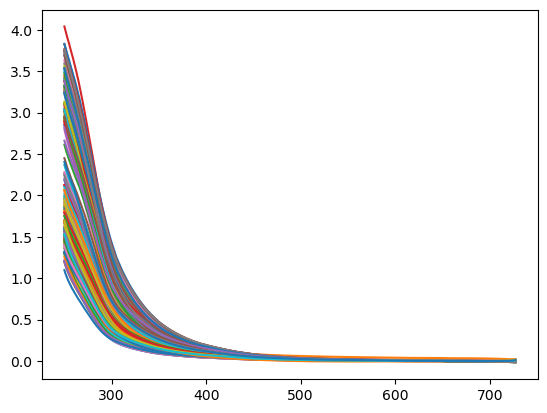

In [ ]:
# quick loop to plot ag vs wavelength for all merged files in selected directory for visual check
import glob
flist = glob.glob('merged_files/KORUS/*.sb')
plt.figure()
for i in flist:
    sb = readSB(filename=i, no_warn=True)
    data = sb.data
    plt.plot(data['wavelength'], data['ag'], label=i.split('_')[3])

In [92]:
make_data_csv(merge[0])

['250,2.485841',
 '251,2.443664',
 '252,2.402785',
 '253,2.364530',
 '254,2.331417',
 '255,2.295758',
 '256,2.263223',
 '257,2.229168',
 '258,2.200828',
 '259,2.170986',
 '260,2.139328',
 '261,2.107893',
 '262,2.080460',
 '263,2.040580',
 '264,2.011095',
 '265,1.987761',
 '266,1.956166',
 '267,1.918419',
 '268,1.886061',
 '269,1.851744',
 '270,1.824517',
 '271,1.784129',
 '272,1.752704',
 '273,1.712484',
 '274,1.675188',
 '275,1.645853',
 '276,1.609527',
 '277,1.569798',
 '278,1.534176',
 '279,1.496107',
 '280,1.456791',
 '281,1.415302',
 '282,1.379170',
 '283,1.343575',
 '284,1.315824',
 '285,1.280045',
 '286,1.245493',
 '287,1.203462',
 '288,1.177949',
 '289,1.139786',
 '290,1.108042',
 '291,1.077894',
 '292,1.048070',
 '293,1.015642',
 '294,0.987101',
 '295,0.961844',
 '296,0.936239',
 '297,0.905195',
 '298,0.881283',
 '299,0.860611',
 '300,0.838057',
 '301,0.815329',
 '302,0.795664',
 '303,0.776152',
 '304,0.759308',
 '305,0.740807',
 '306,0.722140',
 '307,0.705278',
 '308,0.688464

In [91]:
merge[0]

,ultra_ag,cary_ag,vth_merge
wavelength,,,
201.0,NaN,NaN,NaN
202.0,NaN,NaN,NaN
203.0,NaN,NaN,NaN
204.0,NaN,NaN,NaN
205.0,NaN,NaN,NaN
...,...,...,...
796.0,NaN,0.027615,NaN
797.0,NaN,0.026082,NaN
798.0,NaN,0.025582,NaN


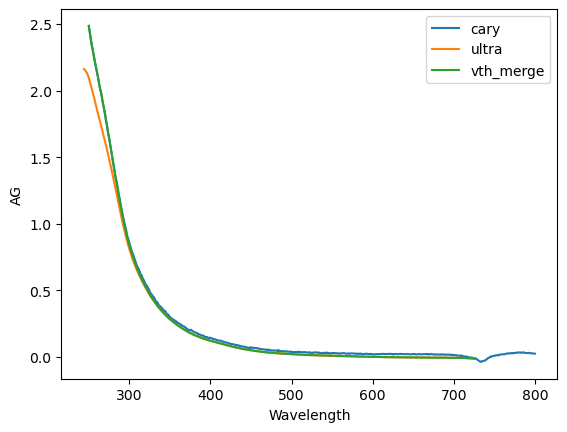

In [50]:
plt.plot(merge[0].index, merge[0]['cary_ag'], label='cary')
plt.plot(merge[0].index, merge[0]['ultra_ag'], label='ultra')
plt.plot(merge[0].index, merge[0]['vth_merge'], label='vth_merge')
plt.xlabel('Wavelength')
plt.ylabel('AG')
plt.legend()
plt.show()

In [58]:
merge_headers = ultra_sb.headers
merge_headers
#merge_headers['data_file_name'] = 

OrderedDict([('received', '20251220'),
             ('identifier_product_doi', '10.5067/SeaBASS/CLIVEC/DATA001'),
             ('investigators', 'Antonio_Mannino,Graham_Trolley,Michael_Novak'),
             ('affiliations',
              'NASA_Goddard_Space_Flight_Center,NASA_Goddard_Space_Flight_Center,Alfred-Wegener-Institute_Helmholtz_Centre_for_Polar_and_Marine_Research'),
             ('contact',
              'antonio.mannino-1@nasa.gov,graham.r.trolley@nasa.gov,michael.novak@ssaihq.com'),
             ('experiment', 'CliVEC'),
             ('cruise', 'CV3'),
             ('station', '68'),
             ('data_file_name',
              'CliVEC_CV3_Ultrapath_waveguide_ag_20100215_st68_00m_R1.sb'),
             ('documents',
              'NACL_curve20100820.csv,CDOM_analysis_checklist_CV3.docx'),
             ('calibration_files', 'see_documents'),
             ('data_type', 'scan'),
             ('start_date', '20100215'),
             ('end_date', '20100215'),
             ('sta

In [7]:
# test files: 
# CLIVAR_P16S_Ultrapath_waveguide_ag_20140421_st55_60m_R1.sb
# CLIVAR_p16s_cary100_ag_20140421_st55_60m.sb

# CliVEC_CV3_Ultrapath_waveguide_ag_20100215_st68_00m_R1.sb
# CV3_ag_st68_00m.sb